In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qls
from molecules import CaOH, CaH, mu_N, gI
import pandas as pd
from scipy.constants import h, k
%matplotlib inline

In [44]:
b_field_gauss = 3.6
j_max = 2

# I compute the molecule 
cah1 = CaH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)


temperature = 300
states1 = qls.States(cah1, temperature)

print(len(cah1.state_df))
print(len(states1.dist))
print("states1.dist = ", states1.dist)

# len(states1.dist) = len(cah1.states_df)

# # I take the transition_df. For each j (multiplet), i take the energy difference of the target distribution.
# signature_transitions = np.array([cah1.transition_df.loc[cah1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(cah1.j_max+1)])


# Then I apply the external Raman pulse. 
duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*0.005
max_frequency_mhz = 0.05
scan_points = 1000
dephased = False
is_minus = True

# get_spectrum: it takes excitation probability (from get_excitation_probabilities) + states1.dist distribution (from States) and np.dot @ freq.
# Then repeats for the frequencies and returns both the frequencies and the results @ each freq.
# This returns the spectrum before pumping.
frequencies, exc_probs1_before = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)
print("EXTERNAL PULSE APPLIED TO COMPUTE THE SPECTRUM")
# print("states1.dist = ", states1.dist)


# Then I pump the system n times to improve the population
pump_frequency_mhz = -0.006
num_pumps = 1
pump_dephased = True
pump_rabi_rate_mhz = 2*np.pi*0.004
pump_duration_us = 1000.0


# I update the state distribution (@ fixed j) with the exctiation matrix.
# I pump the system multiple times in order to better populate the molecule

for _ in range(num_pumps):
    exc_matr = qls.excitation_matrix(cah1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, pump_dephased, is_minus)
    print(exc_matr)
    states1.dist = states1.dist + exc_matr.dot(states1.dist)

print("AFTER 1 PUMPING")
print("states1.dist = ", states1.dist)
print(sum(states1.dist))
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(frequencies, exc_probs1_before, label = "Before")     # Plot before

# frequencies, exc_probs1_after = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

# ax.plot(frequencies, exc_probs1_after, label = f"Rabi rate = {rabi_rate_mhz/(2*np.pi):.3f}")      # Plot after
# ax.bar(signature_transitions, states1.j_distribution(), color="red", width=0.0005, alpha=0.1, label = "Ideal")
# ax.legend()
# ax.set_xlabel("Frequency (MHz)")
# ax.set_ylabel("Excitation probability")
# ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
# ax.set_xlim([-max_frequency_mhz, ])
# ax.set_ylim([0, 0.2])
# plt.show()

#   (2, 3)	0.01434569974203151 * 0.05809216
#   (2, 5)	6.520164772750992e-05 * 0.05809216

# = 0.05892932

18
18
states1.dist =  [0.06083124 0.06083124 0.05809216 0.05809216 0.05809216 0.05809216
 0.05809216 0.05809216 0.05297845 0.05297845 0.05297845 0.05297845
 0.05297845 0.05297845 0.05297845 0.05297845 0.05297845 0.05297845]
EXTERNAL PULSE APPLIED TO COMPUTE THE SPECTRUM
<Compressed Sparse Row sparse array of dtype 'float64'
	with 38 stored elements and shape (18, 18)>
  Coords	Values
  (2, 3)	0.01434569974203151
  (2, 5)	6.520164772750992e-05
  (3, 3)	-0.01434569974203151
  (3, 4)	0.10293713610774338
  (3, 6)	0.00015457758804222015
  (4, 4)	-0.10316806709799259
  (4, 7)	1.8208139227544877e-05
  (5, 4)	0.0002309309902492002
  (5, 5)	-6.520164772750992e-05
  (5, 6)	0.00645667893030891
  (6, 6)	-0.0066112565183511305
  (6, 7)	0.011513117199443966
  (7, 7)	-0.011531325338671511
  (8, 9)	0.0026348653464122176
  (8, 13)	0.00014360421413962574
  (9, 9)	-0.0026348653464122176
  (9, 10)	0.044716495400968725
  (9, 14)	7.034356761148768e-05
  (10, 10)	-0.04474080808812065
  (10, 11)	0.06144238045

In [45]:
0.01434569974203151 * 0.05809216 + 6.520164772750992e-05 * 0.05809216 + 0.05809216

0.0589293203892781

In [9]:
from scipy.constants import h, physical_constants

# matplotlib.use("TkAgg")

# physical constants
mu_N = physical_constants["nuclear magneton"][0]

print(h)
            states_in_j = self.state_df.loc[self.state_df["j"] == j]
            states_index = states_in_j.index.to_numpy()
            states_array = states_in_j.to_numpy()
            m_len = 2 * j + 1

6.62607015e-34


In [25]:
path = "/home/sdruci/master_thesis/molecule_data/CaH_B[6.50]_Jmax[15]_states.csv"

j = 2

df = pd.read_csv(path)
df = df.loc[df["j"] == j]
index = df.index.to_numpy()
array = df.to_numpy()

In [39]:
m1 = -0.5
xi1 = True

energy1 = df.loc[(df["j"] == j) & (df["m"] == m1) & (df["xi"] == xi1)].iloc[0].zeeman_energy_khz
print(energy1)

-19.57487572981429


In [12]:
states_in_j = df.loc[df["j"] == j]
# transitions_in_j = self.transition_df[self.transition_df["j"] == j]
# m = states_in_j["m"].to_numpy()
# energies = states_in_j["zeeman_energy_khz"].to_numpy()
spin_up = states_in_j["spin_up"].to_numpy()
spin_down = states_in_j["spin_down"].to_numpy()
colors = spin_up**2 - spin_down**2

In [13]:
print(spin_up)
print(spin_down)
print(colors)

[0.         0.32743268 0.29810328 0.24490803 0.1723836  0.94487451
 0.95453362 0.96954631 0.98502989 1.        ]
[ 1.         -0.94487451 -0.95453362 -0.96954631 -0.98502989  0.32743268
  0.29810328  0.24490803  0.1723836   0.        ]
[-1.         -0.78557568 -0.82226887 -0.88004011 -0.94056779  0.78557568
  0.82226887  0.88004011  0.94056779  1.        ]


In [35]:
for idx, state1 in enumerate(array):
    print(idx, state1)
    idx1 = index[idx]
    print(idx1)

0 [2 -2.5 False 0.0 1.0 -8.15906431054296 864.0]
8
1 [2 -1.5 False 0.3274326770265168 -0.9448745112528164 5.791791608458264
 864.0]
9
2 [2 -0.5 False 0.2981032781034681 -0.9545336220290862 17.09650331528077
 864.0]
10
3 [2 0.5 False 0.2449080338022826 -0.96954631399387 27.47189689054381 864.0]
11
4 [2 1.5 False 0.1723836013042536 -0.9850298949785108 37.32545449360937
 864.0]
12
5 [2 -1.5 True 0.9448745112528164 0.3274326770265168 -21.74690885205884
 864.0]
13
6 [2 -0.5 True 0.9545336220290862 0.2981032781034681 -19.57487572981429
 864.0]
14
7 [2 0.5 True 0.96954631399387 0.2449080338022826 -16.473524476010283 864.0]
15
8 [2 1.5 True 0.9850298949785108 0.1723836013042536 -12.8503372500088 864.0]
16
9 [2 2.5 True 1.0 0.0 -8.88093568945704 864.0]
17


In [62]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from math import sqrt
from typing import TypeAlias
from pathlib import Path
from wigners import clebsch_gordan
from scipy.constants import h, physical_constants

# matplotlib.use("TkAgg")
%matplotlib inline
# physical constants
mu_N = physical_constants["nuclear magneton"][0]    # J / T
gI = physical_constants["proton g factor"][0]


class CaH:
    name: str = "CaH"
    """name of the molecule"""
    gj: float = -1.36
    """g factor for J"""
    cij_khz: float = 8.52   # kHz
    """coupling strength between proton spin and molecule rotation, in kHz"""
    br_ghz: float = 144.0   # Hz
    """rotational constant, in Hz"""
    omega_0_thz: float = 750.0      # THz
    """frequency of the electronic transition between ground state and 1st excited state, in THz"""
    omega_thz: float = 285.5    # THz
    """frequency of the Raman beam, in THz"""
    coupling_coefficient: float = 1.
    """coupling coefficient, for now to be able to compare with the NIST value"""

    def __init__(self, b_field_gauss: float, j_max: int) -> None:
        self.b_field_gauss = b_field_gauss
        """magnetic field in Gauss"""

        self.j_max = j_max
        """maximum j value to consider"""

        self.cb_khz = mu_N * b_field_gauss * 1e-4 / h / 1e3     # h [J Hz^-1], so cb_khz is in kHz
        """zeeman coefficient mu_N * B / h"""

        self.state_df: pd.DataFrame = pd.DataFrame()
        self.state_df_columns = ["j", "m", "xi", "spin_up", "spin_down", "zeeman_energy_khz", "rotation_energy_ghz"]
        """
        j: int, the j value of the state
        m: int, the m value of the state
        xi: Xi, the xi value of the state, boolean, False for Xi.minus and True for Xi.plus
        spin_up: float, the component for state with nuclear spin aligned to rotation
        spin_down: float, the component for state with nuclear spin anti-aligned to rotation
        zeeman_energy_khz: float, the Zeeman energy in kHz
        rotation_energy_ghz: float, the rotational energy in GHz
        """

        self.transition_df: pd.DataFrame = pd.DataFrame()
        self.transition_df_columns = ["j", "m1", "xi1", "m2", "xi2", "index1", "index2", "energy_diff", "coupling"]
        """
        j: int, the j value of the state
        m1: int, the m value of the initial state
        xi1: Xi, the xi value of the initial state, boolean, False for Xi.minus and True for Xi.plus
        m2: int, the m value of the final state
        xi2: Xi, the xi value of the final state, boolean, False for Xi.minus and True for Xi.plus
        energy_diff: float, the energy difference between the final and initial state in kHz
        coupling: float, the coupling strength between the initial and final state
        """

    @classmethod
    def from_file(cls, b_field_gauss: float, j_max: int):
        """
        Load the molecule data from the file. If the file does not exist, calculate the data from the scratch.
        """
        new_instance = cls(b_field_gauss, j_max)
        states_file = Path(f"molecule_data/{cls.name}_B[{b_field_gauss:.2f}]_Jmax[{j_max}]_states.csv")
        transitions_file = Path(f"molecule_data/{cls.name}_B[{b_field_gauss:.2f}]_Jmax[{j_max}]_transitions.csv")
        if states_file.exists() and transitions_file.exists():
            new_instance.state_df = pd.read_csv(states_file)
            new_instance.transition_df = pd.read_csv(transitions_file)
        else:
            new_instance.init_states()
            new_instance.init_transition_dataframe()
            new_instance.save_data()
        return new_instance

    @classmethod
    def from_calculation(cls, b_field_gauss: float, j_max: int):
        """
        Calculate the molecule data from the scratch.
        """
        new_instance = cls(b_field_gauss, j_max)
        new_instance.init_states()
        new_instance.init_transition_dataframe()
        new_instance.save_data()
        return new_instance

    @classmethod
    def get_m_minus_in_j(cls, j: int) -> np.array:
        """
        j = 4
        np.arange(-j - 0.5, j, 1) --> [-4.5 -3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5]
        """
        return np.arange(-j - 0.5, j, 1)

    @classmethod
    def get_m_plus_in_j(cls, j: int) -> np.array:
        """
        j = 4
        np.arange(-j - 0.5, j, 1) --> [-3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5  4.5]
        """
        return np.arange(-j + 0.5, j + 1, 1)

    def init_states(self):
        """
        Initialize the states in a given j value.
        Calculate the Zeeman energy and the state vector for each state.
        The results are stored in the state_df as a Pandas dataframe.
        States are listed in the order of J values, starting from the lowest J to J_max.
        For each J, first Xi.minus and then Xi.plus states.
        The states of each Xi manifold are listed in the order of m values, starting from the lowest m to the highest m.
        """
        # sta funzione qua non è per nulla efficiente. funziona, ma si ricalcola 2 volte il ciclo for per m, per la maggior parte dei 
        # valori, a parte per gli estremi che sono casi particolari
        for j in range(self.j_max + 1):
            rotation_energy_ghz = self.br_ghz * j * (j + 1)
            state_list = []

            xi = False  # calculate Xi.minus states; "csi = -" con j = 2, vale per gli m che vanno da -5/2 a +3/2, perchè 5/2 è per csi=+
            for m in self.get_m_minus_in_j(j):
                # MAYBE IMPROVEMENTS: it's not efficient to compute x and y here, better inside the x condition.
                # MAYBE IMPROVEMENTS: y is not needed afterwards
                x = 1 / 2 * sqrt(self.cij_khz**2 * ((j + 1 / 2) ** 2 - m**2) + (self.cij_khz * m - self.cb_khz * (self.gj - gI)) ** 2)
                y = -self.cb_khz / 2 * (self.gj - gI) + m * self.cij_khz / 2    # MAYBE ERROR: the + i think should be a -
                if m == -j - 0.5:
                    spin_up = 0.0
                    spin_down = 1.0
                    zeeman_energy_khz = (self.gj * j + gI / 2) * self.cb_khz - self.cij_khz * j / 2     # MAYBE ERROR: the - i think should be a +
                    state_list.append([j, float(m), xi, spin_up, spin_down, zeeman_energy_khz, rotation_energy_ghz])
                else:
                    spin_up = sqrt((x - y) / (2 * x))
                    spin_down = -sqrt((x + y) / (2 * x))
                    zeeman_energy_khz = self.cij_khz / 4 - self.cb_khz * self.gj * m + x
                    state_list.append([j, float(m), xi, spin_up, spin_down, zeeman_energy_khz, rotation_energy_ghz])

            xi = True  # calculate Xi.plus states
            for m in self.get_m_plus_in_j(j):
                x = 1 / 2 * sqrt(self.cij_khz**2 * ((j + 1 / 2) ** 2 - m**2) + (self.cij_khz * m - self.cb_khz * (self.gj - gI)) ** 2)
                y = -self.cb_khz / 2 * (self.gj - gI) + m * self.cij_khz / 2
                if m == j + 0.5:
                    spin_up = 1.0
                    spin_down = 0.0
                    zeeman_energy_khz = -(self.gj * j + gI / 2) * self.cb_khz - self.cij_khz * j / 2
                    state_list.append([j, float(m), xi, spin_up, spin_down, zeeman_energy_khz, rotation_energy_ghz])
                else:
                    spin_up = sqrt((x + y) / (2 * x))
                    spin_down = sqrt((x - y) / (2 * x))
                    zeeman_energy_khz = self.cij_khz / 4 - self.cb_khz * self.gj * m - x
                    state_list.append([j, float(m), xi, spin_up, spin_down, zeeman_energy_khz, rotation_energy_ghz])

            self.state_df = pd.concat([self.state_df, pd.DataFrame(state_list, columns=self.state_df_columns)], ignore_index=True)

    def init_transition_dataframe(self):
        """
        Initialize the transition dataframe.
        """
        for j in range(self.j_max + 1):
            states_in_j = self.state_df.loc[self.state_df["j"] == j]
            states_index = states_in_j.index.to_numpy()
            states_array = states_in_j.to_numpy()
            m_len = 2 * j + 1
            transition_list = []

            # index1 --> index2
            for index, state1 in enumerate(states_array):
                index1 = states_index[index]
                m1, xi1, zeeman_energy_khz1 = state1[1], state1[2], state1[5]

                if index == 0:  # no transition from the Xi.minus left edge state
                    continue

                if index == 1 or index == m_len:
                    # the states right next to the Xi.minus left edge state
                    index2 = states_index[0]    # è in numero della riga del final state nel df. 
                    state2 = states_array[0]    # è la riga del final state nel df.
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]

                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, 0, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])
                    continue
                
                # transizione sullo stesso piano
                index2 = states_index[index - 1]
                state2 = states_array[index - 1]
                m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, 0, -1)
                transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])

                # transizione su piano opposto
                if xi1:  # Xi.plus
                    index2 = states_index[index - m_len]
                    state2 = states_array[index - m_len]
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, 0, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])
                else:  # Xi.minus
                    index2 = states_index[index + m_len - 2]
                    state2 = states_array[index + m_len - 2]
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, 0, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])

            self.transition_df = pd.concat([self.transition_df, pd.DataFrame(transition_list, columns=self.transition_df_columns)], ignore_index=True)

    def get_raman_coupling(self, index1, index2, qa, qb):
        """
        Calculates the coupling between two Zeeman levels, |m1,xi1> & |m2,xi2>
        with two Raman beam with polarization qa and qb.
        Detuning and the electronic transition term is not considered.
        """

        def j_coupling(j, j_exc, mj1, mj2, qa, qb) -> float:
            if j < 0 or j_exc < 0:
                return 0
            if j < abs(mj1) or j < abs(mj2) or j_exc < abs(mj1 + qa):
                return 0
            return (
                np.sqrt((2 * j_exc + 1) / (2 * j + 1))
                * clebsch_gordan(1, 0, j_exc, 0, j, 0)
                * clebsch_gordan(1, -qa, j_exc, mj1 + qa, j, mj1)
                * np.sqrt((2 * j + 1) / (2 * j_exc + 1))
                * clebsch_gordan(1, 0, j, 0, j_exc, 0)
                * clebsch_gordan(1, -qb, j, mj2, j_exc, mj1 + qa)
            )

        state1 = self.state_df.loc[index1]
        state2 = self.state_df.loc[index2]
        j = state1.j
        m1 = state1.m
        m2 = state2.m
        m1_up = int(m1 - 0.5)
        m1_down = int(m1 + 0.5)
        m2_up = int(m2 - 0.5)
        m2_down = int(m2 + 0.5)

        coupling_minus = (
            1.0
            / (self.omega_thz - self.omega_0_thz)
            * (
                state1.spin_down * state2.spin_down * j_coupling(j, j + 1, m1_down, m2_down, qa, qb)
                + state1.spin_down * state2.spin_up * j_coupling(j, j + 1, m1_down, m2_up, qa, qb)
                + state1.spin_up * state2.spin_down * j_coupling(j, j + 1, m1_up, m2_down, qa, qb)
                + state1.spin_up * state2.spin_up * j_coupling(j, j + 1, m1_up, m2_up, qa, qb)
                + state1.spin_down * state2.spin_down * j_coupling(j, j - 1, m1_down, m2_down, qa, qb)
                + state1.spin_down * state2.spin_up * j_coupling(j, j - 1, m1_down, m2_up, qa, qb)
                + state1.spin_up * state2.spin_down * j_coupling(j, j - 1, m1_up, m2_down, qa, qb)
                + state1.spin_up * state2.spin_up * j_coupling(j, j - 1, m1_up, m2_up, qa, qb)
            )
        )

        coupling_plus = (
            1.0
            / (self.omega_0_thz + self.omega_thz)
            * (
                state1.spin_down * state2.spin_down * j_coupling(j, j + 1, m1_down, m2_down, qb, qa)
                + state1.spin_down * state2.spin_up * j_coupling(j, j + 1, m1_down, m2_up, qb, qa)
                + state1.spin_up * state2.spin_down * j_coupling(j, j + 1, m1_up, m2_down, qb, qa)
                + state1.spin_up * state2.spin_up * j_coupling(j, j + 1, m1_up, m2_up, qb, qa)
                + state1.spin_down * state2.spin_down * j_coupling(j, j - 1, m1_down, m2_down, qb, qa)
                + state1.spin_down * state2.spin_up * j_coupling(j, j - 1, m1_down, m2_up, qb, qa)
                + state1.spin_up * state2.spin_down * j_coupling(j, j - 1, m1_up, m2_down, qb, qa)
                + state1.spin_up * state2.spin_up * j_coupling(j, j - 1, m1_up, m2_up, qb, qa)
            )
        )

        return (coupling_minus + coupling_plus) / (1.0 / (self.omega_thz - self.omega_0_thz) + 1.0 / (self.omega_0_thz + self.omega_thz))

    def plot_zeeman_levels(self, j: int):
        """
        Plot the Zeeman energies of all states in a given j value.
        """
        states_in_j = self.state_df.loc[self.state_df["j"] == j]
        transitions_in_j = self.transition_df[self.transition_df["j"] == j]
        m = states_in_j["m"].to_numpy()
        energies = states_in_j["zeeman_energy_khz"].to_numpy()
        spin_up = states_in_j["spin_up"].to_numpy()
        spin_down = states_in_j["spin_down"].to_numpy()
        colors = spin_up**2 - spin_down**2

        # print("Colors:", colors)

        fig, ax = plt.subplots(figsize=(12, 8))
        # ax.scatter(m, energies, c=colors, label = f"{colors}")

        ax.scatter(m, energies, marker="_", c=colors, label = f"{colors}", cmap="plasma", s=500, linewidths=5)
        ax.set_xlabel("m")
        ax.set_ylabel("Zeeman energy (kHz)")
        ax.set_title(f"Zeeman energies of all states in j={j}, B={self.b_field_gauss} G")
        ax.legend()
        fig.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-1, vmax=1), cmap="plasma"), ax=ax)

        # plot the difference between neibouring states on arrows conecting them
        for transition in transitions_in_j.itertuples():
            m1 = transition.m1
            xi1 = transition.xi1
            energy1 = self.state_df.loc[(self.state_df["j"] == j) & (self.state_df["m"] == m1) & (self.state_df["xi"] == xi1)].iloc[0].zeeman_energy_khz
            m2 = transition.m2
            xi2 = transition.xi2
            energy2 = self.state_df.loc[(self.state_df["j"] == j) & (self.state_df["m"] == m2) & (self.state_df["xi"] == xi2)].iloc[0].zeeman_energy_khz
            energy_diff = transition.energy_diff
            coupling = transition.coupling
            ax.arrow(float(m1), float(energy1), -1.0, float(energy_diff), head_width=0.1, head_length=0.1, linestyle="dotted", color="black")
            # add the energy difference as text on the arrow
            ax.text((m1 + m2) / 2.0 - 0.2, (energy1 + energy2) / 2.0, f"{energy_diff:.3f}", fontsize=10)
            # add the coupling strength as text on the arrow
            ax.text((m1 + m2) / 2.0, (energy1 + energy2) / 2.0 - 0.9, f"{coupling:.3f}", fontsize=10, color="red")

        plt.show()
        plt.close()

    def save_data(self):
        self.state_df.to_csv(f"molecule_data/{self.name}_B[{self.b_field_gauss:.2f}]_Jmax[{self.j_max}]_states.csv", index=False)
        self.transition_df.to_csv(f"molecule_data/{self.name}_B[{self.b_field_gauss:.2f}]_Jmax[{self.j_max}]_transitions.csv", index=False)


class CaOH(CaH):
    name: str = "CaOH"
    """name of the molecule"""
    gj: float = -0.036
    """g factor for J"""
    cij_khz: float = 1.49
    """coupling strength between proton spin and molecule rotation, in kHz"""
    br_ghz: float = 11.0
    """rotational constant, in GHz"""
    omega_0_thz: float = 1100.0
    """frequency of the electronic transition between ground state and 1st excited state, in THz"""
    omega_thz: float = 280.0
    """frequency of the Raman beam, in THz"""
    coupling_coefficient: float = 1.
    """coupling coefficient, for now to be able to compare with the NIST value"""

    def __init__(self, b_field_gauss: float, j_max: int) -> None:
        super().__init__(b_field_gauss, j_max)


class CaOH_dm2(CaH):
    
    # MAYBE IMPROVEMENTS: ridefinito funzioni solo perchè init_transition è diversa.
    # non è molto efficiente, forse conviene fare in un altro modo più compatto.

    name: str = "CaOH_dm2"
    """name of the molecule"""
    gj: float = -0.036
    """g factor for J"""
    cij_khz: float = 1.49
    """coupling strength between proton spin and molecule rotation, in kHz"""
    br_ghz: float = 11.0
    """rotational constant, in GHz"""
    omega_0_thz: float = 1100.0
    """frequency of the electronic transition between ground state and 1st excited state, in THz"""
    omega_thz: float = 280.0
    """frequency of the Raman beam, in THz"""
    coupling_coefficient: float = 1.0
    """coupling coefficient, for now to be able to compare with the NIST value"""

    def __init__(self, b_field_gauss: float, j_max: int) -> None:
        super().__init__(b_field_gauss, j_max)

    @classmethod
    def from_file_dm2(cls, b_field_gauss: float, j_max: int):
        """
        Load the molecule data from the file. If the file does not exist, calculate the data from the scratch.
        """
        new_instance = cls(b_field_gauss, j_max)
        states_file = Path(f"molecule_data/{cls.name}_B[{b_field_gauss:.2f}]_Jmax[{j_max}]_states.csv")
        transitions_file = Path(f"molecule_data/{cls.name}_B[{b_field_gauss:.2f}]_Jmax[{j_max}]_transitions.csv")
        if states_file.exists() and transitions_file.exists():
            new_instance.state_df = pd.read_csv(states_file)
            new_instance.transition_df = pd.read_csv(transitions_file)
        else:
            new_instance.init_states()
            new_instance.init_transition_dm2_dataframe()
            new_instance.save_data()
        return new_instance

    @classmethod
    def from_calculation_dm2(cls, b_field_gauss: float, j_max: int):
        """
        Calculate the molecule data from the scratch.
        """
        new_instance = cls(b_field_gauss, j_max)
        new_instance.init_states()
        new_instance.init_transition_dm2_dataframe()
        new_instance.save_data()
        return new_instance

    def init_transition_dm2_dataframe(self):
        """
        Initialize the transition dataframe.
        """
        for j in range(self.j_max + 1):
            states_in_j = self.state_df.loc[self.state_df["j"] == j]
            states_index = states_in_j.index.to_numpy()
            states_array = states_in_j.to_numpy()
            m_len = 2 * j + 1
            transition_list = []

            
            for index, state1 in enumerate(states_array):
                index1 = states_index[index]
                m1, xi1, zeeman_energy_khz1 = state1[1], state1[2], state1[5]

                if index == 0 or index == 1 or index == m_len:
                    # no transition from the Xi.minus left two edge state
                    # no transition from the Xi.plus left edge state
                    continue

                if index == 2 or index == m_len + 1:
                    # the states right next to the Xi.minus left edge state
                    index2 = states_index[0]
                    state2 = states_array[0]
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]

                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, -1, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])
                    continue

                index2 = states_index[index - 2]
                state2 = states_array[index - 2]
                m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, -1, -1)
                transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])

                if xi1:  # Xi.plus
                    index2 = states_index[index - m_len - 1]
                    state2 = states_array[index - m_len - 1]
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, -1, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])
                else:  # Xi.minus
                    index2 = states_index[index + m_len - 3]
                    state2 = states_array[index + m_len - 3]
                    m2, xi2, zeeman_energy_khz2 = state2[1], state2[2], state2[5]
                    energy_diff = zeeman_energy_khz2 - zeeman_energy_khz1
                    coupling = self.coupling_coefficient * self.get_raman_coupling(index1, index2, -1, -1)
                    transition_list.append([j, m1, xi1, m2, xi2, index1, index2, energy_diff, coupling])

            self.transition_df = pd.concat([self.transition_df, pd.DataFrame(transition_list, columns=self.transition_df_columns)], ignore_index=True)

    def plot_zeeman_levels_dm2(self, j: int):
        # MAYBE IMPROVEMENT: controllare se questa funzione è uguale a quella di CaH, che se lo è probabilmente 
        # si può cancellare
        """
        Plot the Zeeman energies of all states in a given j value.
        """
        states_in_j = self.state_df.loc[self.state_df["j"] == j]
        transitions_in_j = self.transition_df[self.transition_df["j"] == j]
        m = states_in_j["m"].to_numpy()
        energies = states_in_j["zeeman_energy_khz"].to_numpy()
        spin_up = states_in_j["spin_up"].to_numpy()
        spin_down = states_in_j["spin_down"].to_numpy()
        colors = spin_up**2 - spin_down**2

        

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.scatter(m, energies, marker="_", c=colors, label =f"{colors}", cmap="plasma", s=500, linewidths=5)
        ax.set_xlabel("m")
        ax.set_ylabel("Zeeman energy (kHz)")
        ax.set_title(f"Zeeman energies of all states in j={j}, B={self.b_field_gauss} G")
        fig.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-1, vmax=1), cmap="plasma"), ax=ax)
        

        # plot the difference between neibouring states on arrows conecting them
        for transition in transitions_in_j.itertuples():
            m1 = transition.m1
            xi1 = transition.xi1
            energy1 = self.state_df.loc[(self.state_df["j"] == j) & (self.state_df["m"] == m1) & (self.state_df["xi"] == xi1)].iloc[0].zeeman_energy_khz
            m2 = transition.m2
            xi2 = transition.xi2
            energy2 = self.state_df.loc[(self.state_df["j"] == j) & (self.state_df["m"] == m2) & (self.state_df["xi"] == xi2)].iloc[0].zeeman_energy_khz
            energy_diff = transition.energy_diff
            coupling = transition.coupling
            ax.arrow(float(m1), float(energy1), -2.0, float(energy_diff), head_width=0.1, head_length=0.1, linestyle="dotted", color="black")
            # add the energy difference as text on the arrow
            ax.text((m1 + m2) / 2.0 - 0.2, (energy1 + energy2) / 2.0, f"{energy_diff:.3f}", fontsize=10)
            # add the coupling strength as text on the arrow
            ax.text((m1 + m2) / 2.0, (energy1 + energy2) / 2.0 - 0.9, f"{coupling:.3f}", fontsize=10, color="red")

        
        plt.show()
        plt.close()


Molecule: TypeAlias = CaH | CaOH | CaOH_dm2

if __name__ == "__main__":
    # test = CaH(6.5)
    # J = 6
    # test.plot_zeeman_levels(J, include_j_to_j=False)
    test2 = CaOH(3.1, 30)
    J = 2
    # test2.init_transition_dataframe(J)
    # J = 1
    # test2.init_transition_dataframe(J)
    # print(test2.)
    # test2.plot_zeeman_levels(J)


In [23]:
cah = CaH.from_file(b_field_gauss=6.5, j_max=15)

Colors: [-1.         -0.78557568 -0.82226887 -0.88004011 -0.94056779  0.78557568
  0.82226887  0.88004011  0.94056779  1.        ]


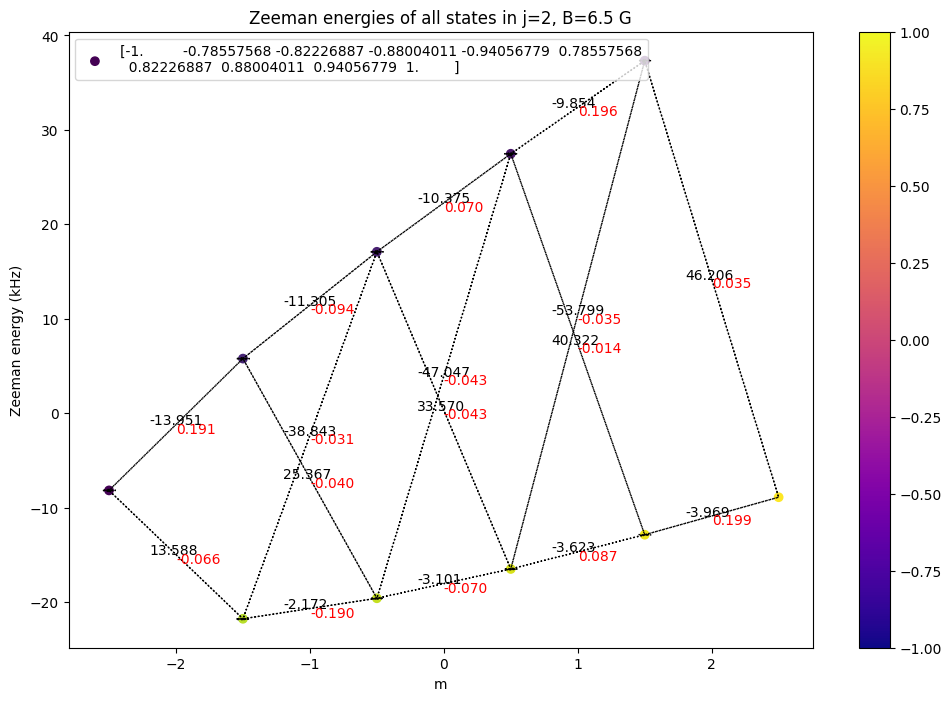

In [24]:
cah.plot_zeeman_levels(2)

In [60]:
caoh = CaOH.from_file(b_field_gauss=3.1, j_max=50)

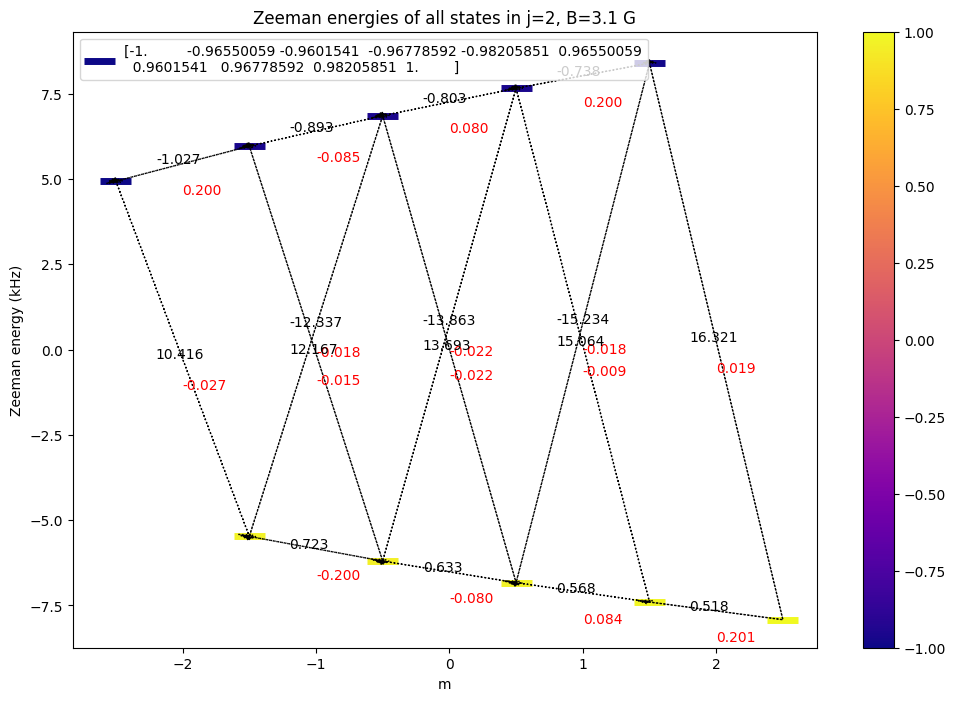

In [61]:
caoh.plot_zeeman_levels(2)
